# Publication figures

Produces the main biology figure, the supplementary classifier figure, and the supporting CSVs for the manuscript. Both figures are per-cell where applicable, with OOF aggregation across all 5 CV folds for classifier panels (n ≈ 1100 cells).

Main figure (1×3):

| (A) | (B) | (C) |
|---|---|---|
| per-cell classifier ROC, OOF across 5 folds | polymer length / 100 cells per FOV, half-violin half-whisker | mean sickle fraction per condition, one dot per condition |

Supplementary figure (1×3, per-cell OOF):

| (A) | (B) | (C) |
|---|---|---|
| PR curve with bootstrap CI | confusion matrix at MCC-maximizing threshold | calibration plot |

Outputs in `figures/<YYYY-MM-DD>/`:

* `main_figure_biology.svg` / `.png` — the main 1×3 figure.
* `main_figure_stats.csv` — A vs S-UNT effect sizes (Cohen's d, Cliff's δ, MWU, BH-FDR) and per-cell ROC-AUC. Now includes a third row for polymer-µm per sickle cell.
* `panel_B_per_group_polymer.csv` — per-group polymer length / 100 cells summary, with cell-count and FOV-count stats.
* `panel_B_polymer_per_sickle.csv` — per-condition distribution shape (n, mean, median, SD, IQR, skew, Fisher kurtosis) of polymer µm per sickle cell, derived from xlsx (`polymer_length_um / n_sickle` per FOV).
* `panel_C_mean_sickle_fraction.csv` — per-condition mean sickle fraction with SEM and SD.
* `supplementary_figure_Y.svg` / `.png` — composite supplementary.
* `panel_A_pr_curve.svg/.pdf`, `panel_C_calibration.svg/.pdf` — standalone supplementary panels.

Conventions: SLHi-2 dropped (mislabel). Group A pools A-UNT + ALLo + ALHi. Outlier rule: Tukey outer fence k=3, per group, per metric.

In [1]:
import sys
from pathlib import Path
from datetime import date

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats as _stats
from scipy.stats import gaussian_kde
from sklearn.metrics import roc_auc_score, roc_curve

mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["pdf.fonttype"] = 42

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from sickling.rbc_classification.py_modules.eval.report import read_report

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: E:\utku g leica\rbc-class


In [2]:
TODAY = date.today().isoformat()
out_dir = REPO_ROOT / "figures" / TODAY
out_dir.mkdir(parents=True, exist_ok=True)

XLSX_PATH = REPO_ROOT / "sickling-poster" / "classification_results.xlsx"

EVAL_BASE = REPO_ROOT / "figures" / "2026-05-18" / "eval"
MODEL_STEM = "multimodal_dinov2_frozen_image+morphology"
N_FOLDS = 5
FOLD_REPORT_PATHS = [
    EVAL_BASE / f"{MODEL_STEM}_fold{k}" / "report.json" for k in range(N_FOLDS)
]

print("out_dir:", out_dir)
print(f"  exists={XLSX_PATH.exists()!s:5s}  {XLSX_PATH}")
print("fold reports:")
for p in FOLD_REPORT_PATHS:
    print(f"  exists={p.exists()!s:5s}  {p}")

out_dir: E:\utku g leica\rbc-class\figures\2026-06-09
  exists=True   E:\utku g leica\rbc-class\sickling-poster\classification_results.xlsx
fold reports:
  exists=True   E:\utku g leica\rbc-class\figures\2026-05-18\eval\multimodal_dinov2_frozen_image+morphology_fold0\report.json
  exists=True   E:\utku g leica\rbc-class\figures\2026-05-18\eval\multimodal_dinov2_frozen_image+morphology_fold1\report.json
  exists=True   E:\utku g leica\rbc-class\figures\2026-05-18\eval\multimodal_dinov2_frozen_image+morphology_fold2\report.json
  exists=True   E:\utku g leica\rbc-class\figures\2026-05-18\eval\multimodal_dinov2_frozen_image+morphology_fold3\report.json
  exists=True   E:\utku g leica\rbc-class\figures\2026-05-18\eval\multimodal_dinov2_frozen_image+morphology_fold4\report.json


In [3]:
raw_single = pd.read_excel(XLSX_PATH, sheet_name="single")

RENAME = {
    "Condition name": "condition",
    "image name": "image_name",
    "# of sickle": "n_sickle",
    "# of non-sickle": "n_non_sickle",
    "polymer length (um)": "polymer_length_um",
    "polymer length / 100 cells (um)": "polymer_um_per_100_cells",
}
all_df = raw_single.rename(columns=RENAME).copy()

DROP_CONDITIONS = {"SLHi-2"}
all_df = all_df.loc[~all_df["condition"].isin(DROP_CONDITIONS)].copy()

A_MEMBERS = {"A-UNT", "ALLo", "ALHi"}
all_df["group"] = np.where(all_df["condition"].isin(A_MEMBERS), "A", all_df["condition"])

all_df["n_cells"] = all_df["n_sickle"] + all_df["n_non_sickle"]
all_df["frac_sickle"] = np.where(
    all_df["n_cells"] > 0,
    all_df["n_sickle"] / all_df["n_cells"],
    np.nan,
)

REF_ORDER = ["A", "S-UNT", "SLN1", "SLN2", "SLHi", "SE1", "SE2"]
MAIN_ORDER = ["A", "S-UNT"]

all_df = all_df.loc[all_df["group"].isin(REF_ORDER)].copy()

print("per-group n FOVs:")
print(all_df.groupby("group").size().reindex(REF_ORDER))
print()
print("members of group A:")
print(all_df.loc[all_df["group"] == "A", "condition"].value_counts())

main_df = all_df.loc[all_df["group"].isin(MAIN_ORDER)].copy()
missing = [g for g in MAIN_ORDER if g not in main_df["group"].unique()]
assert not missing, f"Missing required main-figure groups: {missing}"

per-group n FOVs:
group
A        864
S-UNT    992
SLN1     288
SLN2     288
SLHi     288
SE1      288
SE2      288
dtype: int64

members of group A:
condition
A-UNT    288
ALHi     288
ALLo     288
Name: count, dtype: int64


In [4]:
def _bh_fdr(pvalues: np.ndarray) -> np.ndarray:
    arr = np.asarray(pvalues, dtype=float)
    out = np.full_like(arr, np.nan)
    mask = ~np.isnan(arr)
    if mask.sum() == 0:
        return out
    p = arr[mask]
    n = p.size
    order = np.argsort(p)
    ranks = np.arange(1, n + 1)
    p_sorted = p[order]
    adj_sorted = p_sorted * n / ranks
    adj_sorted = np.minimum.accumulate(adj_sorted[::-1])[::-1]
    adj_sorted = np.clip(adj_sorted, 0.0, 1.0)
    adjusted = np.empty(n, dtype=float)
    adjusted[order] = adj_sorted
    out[mask] = adjusted
    return out


def bootstrap_auc(y_true, y_score, n_resamples=1000, alpha=0.05, seed=42):
    y_true = np.asarray(y_true); y_score = np.asarray(y_score)
    n = y_true.shape[0]
    point = float(roc_auc_score(y_true, y_score))
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, n, size=(n_resamples, n))
    vals = np.empty(n_resamples, dtype=np.float64)
    for i in range(n_resamples):
        ii = idx[i]
        yt, ys = y_true[ii], y_score[ii]
        if np.unique(yt).size < 2:
            vals[i] = np.nan; continue
        try:
            vals[i] = roc_auc_score(yt, ys)
        except (ValueError, RuntimeError):
            vals[i] = np.nan
    finite = vals[np.isfinite(vals)]
    if finite.size == 0:
        return point, float("nan"), float("nan")
    lo = float(np.percentile(finite, 100 * alpha / 2))
    hi = float(np.percentile(finite, 100 * (1 - alpha / 2)))
    return point, lo, hi


def cohens_d(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    na, nb = a.size, b.size
    if na < 2 or nb < 2:
        return float("nan")
    va = a.var(ddof=1); vb = b.var(ddof=1)
    pooled = np.sqrt(((na - 1) * va + (nb - 1) * vb) / (na + nb - 2))
    if pooled == 0:
        return float("nan")
    return float((b.mean() - a.mean()) / pooled)


def cliffs_delta(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if a.size == 0 or b.size == 0:
        return float("nan")
    u_b = float(_stats.mannwhitneyu(b, a, alternative="two-sided").statistic)
    return float(2.0 * u_b / (a.size * b.size) - 1.0)


def mwu_two_sided(a, b):
    a = np.asarray(a, dtype=float); b = np.asarray(b, dtype=float)
    if a.size < 2 or b.size < 2:
        return float("nan")
    return float(_stats.mannwhitneyu(a, b, alternative="two-sided").pvalue)


def tukey_outlier_mask(x: np.ndarray, k: float = 3.0) -> np.ndarray:
    """Tukey-fence outlier mask. k=3.0 = outer fence (used here)."""
    x = np.asarray(x, dtype=float)
    out = np.zeros_like(x, dtype=bool)
    finite = np.isfinite(x)
    if finite.sum() < 4:
        return out
    q1, q3 = np.nanpercentile(x[finite], [25, 75])
    iqr = q3 - q1
    if iqr == 0:
        return out
    lo = q1 - k * iqr
    hi = q3 + k * iqr
    out[finite] = (x[finite] < lo) | (x[finite] > hi)
    return out

In [5]:
# Derived metric: average polymer length attributable to one sickle cell in a
# FOV. Undefined where n_sickle == 0.
all_df["polymer_um_per_sickle"] = np.where(
    all_df["n_sickle"] > 0,
    all_df["polymer_length_um"] / all_df["n_sickle"],
    np.nan,
)

all_df["is_outlier_sickle"] = False
all_df["is_outlier_poly"] = False
all_df["is_outlier_polypersickle"] = False
for g in REF_ORDER:
    m = all_df["group"] == g
    all_df.loc[m, "is_outlier_sickle"] = tukey_outlier_mask(
        all_df.loc[m, "frac_sickle"].to_numpy()
    )
    all_df.loc[m, "is_outlier_poly"] = tukey_outlier_mask(
        all_df.loc[m, "polymer_um_per_100_cells"].to_numpy()
    )
    all_df.loc[m, "is_outlier_polypersickle"] = tukey_outlier_mask(
        all_df.loc[m, "polymer_um_per_sickle"].to_numpy()
    )

summary = (
    all_df.groupby("group")
    .agg(
        n=("image_name", "count"),
        n_out_sickle=("is_outlier_sickle", "sum"),
        n_out_poly=("is_outlier_poly", "sum"),
        n_out_polypersickle=("is_outlier_polypersickle", "sum"),
    )
    .reindex(REF_ORDER)
    .reset_index()
)
summary["pct_out_sickle"] = 100.0 * summary["n_out_sickle"] / summary["n"]
summary["pct_out_poly"] = 100.0 * summary["n_out_poly"] / summary["n"]
summary["pct_out_polypersickle"] = 100.0 * summary["n_out_polypersickle"] / summary["n"]
print("Tukey 3·IQR outlier counts per group:")
print(summary.to_string(index=False))

main_df = all_df.loc[all_df["group"].isin(MAIN_ORDER)].copy()

Tukey 3·IQR outlier counts per group:
group   n  n_out_sickle  n_out_poly  n_out_polypersickle  pct_out_sickle  pct_out_poly  pct_out_polypersickle
    A 864            17          34                    8        1.967593      3.935185               0.925926
S-UNT 992             3           1                   13        0.302419      0.100806               1.310484
 SLN1 288             0           0                    0        0.000000      0.000000               0.000000
 SLN2 288             0           0                    1        0.000000      0.000000               0.347222
 SLHi 288             0           1                    5        0.000000      0.347222               1.736111
  SE1 288             0           3                    4        0.000000      1.041667               1.388889
  SE2 288             0           8                    0        0.000000      2.777778               0.000000


In [6]:
OUTLIER_COLOR = "#a8a8a8"
OUTLIER_ALPHA = 0.65
OUTLIER_LW = 0.6
SCATTER_ALPHA = 0.0


def _split(df, group, col, out_col):
    sub = df.loc[df["group"] == group]
    in_mask = (~sub[out_col]) & sub[col].notna()
    out_mask = sub[out_col] & sub[col].notna()
    return sub.loc[in_mask, col].to_numpy(), sub.loc[out_mask, col].to_numpy()


def _half_violin_half_whisker(ax, groups_in, groups_out, labels, ylabel, ylim,
                              violin_color="#c1440e",
                              max_halfwidth=0.36,
                              violin_alpha=0.22,
                              violin_edge_alpha=0.55,
                              seed=0):
    rng = np.random.default_rng(seed)
    for i, (vals_in, vals_out) in enumerate(zip(groups_in, groups_out)):
        x = i + 1
        v = np.asarray(vals_in, dtype=float)
        v = v[np.isfinite(v)]

        if v.size >= 4 and np.std(v) > 0:
            kde = gaussian_kde(v)
            pad = 0.05 * (v.max() - v.min() + 1e-9)
            y = np.linspace(v.min() - pad, v.max() + pad, 256)
            d = kde(y)
            d = d / d.max() * max_halfwidth
            ax.fill_betweenx(y, x, x + d, color=violin_color,
                             alpha=violin_alpha, lw=0, zorder=1)
            ax.plot(x + d, y, color=violin_color, lw=0.8,
                    alpha=violin_edge_alpha, zorder=1)

        if v.size:
            median = float(np.median(v))
            ax.scatter([x + 0.06], [median], s=36, color=violin_color,
                       edgecolors="none", alpha=1.0, zorder=6)

        if v.size >= 2:
            q1 = float(np.quantile(v, 0.25))
            q3 = float(np.quantile(v, 0.75))
            mean = float(np.mean(v))
            X_IQR = x - 0.08
            MEAN_HALFWIDTH = 0.20
            ax.plot([X_IQR, X_IQR], [q1, q3], color="black", lw=2.2, zorder=5)
            ax.plot([x - MEAN_HALFWIDTH, x], [mean, mean],
                    color="black", lw=2.2, zorder=6)

        if vals_out.size:
            jitter = rng.uniform(-0.10, -0.02, size=vals_out.size)
            ax.scatter(np.full_like(vals_out, x) + jitter, vals_out,
                       s=24, marker="x", c=OUTLIER_COLOR,
                       linewidths=OUTLIER_LW, alpha=OUTLIER_ALPHA, zorder=2)

        if v.size:
            ax.scatter(np.full(v.size, x), v, s=22, color="black",
                       alpha=SCATTER_ALPHA, edgecolors="none", zorder=3)

    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels)
    ax.set_ylabel(ylabel)
    ax.set_xlim(0.4, len(labels) + 0.6)
    if ylim is not None:
        ax.set_ylim(*ylim)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_axisbelow(True)
    ax.yaxis.grid(True, linestyle=":", alpha=0.5)


def _panel_label(ax, text):
    ax.text(-0.20, 1.05, text, transform=ax.transAxes,
            fontweight="bold", fontsize=12, va="top", ha="left")

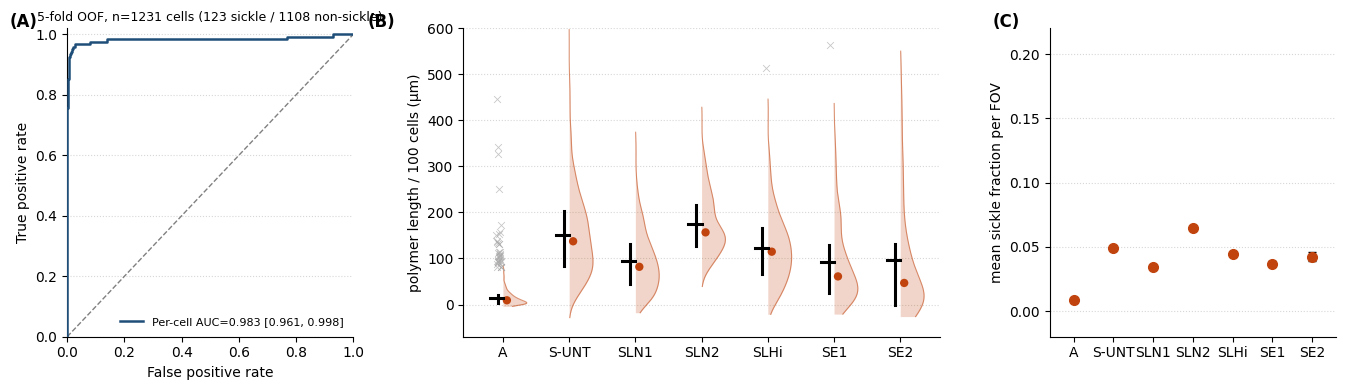

wrote E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_biology.svg
wrote E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_biology.png


In [7]:
POLY_YLIM_FOV = (-70.0, 600.0)
VIOLIN_COLOR = "#c1440e"

# --- Panel A: per-cell OOF ROC across all 5 CV folds -----------------------
fold_y_true, fold_y_score, fold_n = [], [], []
for p in FOLD_REPORT_PATHS:
    rep = read_report(p)
    fold_y_true.append(np.asarray(rep.y_true, dtype=np.int64))
    fold_y_score.append(np.asarray(rep.y_score, dtype=np.float64))
    fold_n.append(int(rep.n_val))

y_true_oof = np.concatenate(fold_y_true)
y_score_oof = np.concatenate(fold_y_score)
n_cells_oof = int(y_true_oof.size)
n_pos_oof = int(y_true_oof.sum())
n_neg_oof = n_cells_oof - n_pos_oof
assert sum(fold_n) == n_cells_oof

auc_cell, lo_cell, hi_cell = bootstrap_auc(y_true_oof, y_score_oof, n_resamples=1000, seed=42)
fpr_cell, tpr_cell, _ = roc_curve(y_true_oof, y_score_oof)

# --- Panel B inputs: per-FOV polymer length / 100 cells (unchanged) --------
groups_polyfov_in, groups_polyfov_out = zip(*[
    _split(all_df, g, "polymer_um_per_100_cells", "is_outlier_poly") for g in REF_ORDER
])

# --- Panel C: mean sickle fraction per condition (one dot per condition) ---
panel_c_rows = []
for g in REF_ORDER:
    sub = all_df.loc[(all_df["group"] == g) & (~all_df["is_outlier_sickle"]),
                     "frac_sickle"].dropna().to_numpy()
    panel_c_rows.append({
        "group": g,
        "n_fovs": int(sub.size),
        "mean_frac_sickle": float(sub.mean()) if sub.size else float("nan"),
        "sem_frac_sickle": float(sub.std(ddof=1) / np.sqrt(sub.size)) if sub.size > 1 else float("nan"),
        "sd_frac_sickle": float(sub.std(ddof=1)) if sub.size > 1 else float("nan"),
    })
panel_c_df = pd.DataFrame(panel_c_rows)

# --- Figure layout: 1x3 row ------------------------------------------------
fig, axes = plt.subplots(
    1, 3, figsize=(13.5, 4.0),
    gridspec_kw={"width_ratios": [3, 5, 3]},
)
ax_a, ax_b, ax_c = axes

# --- (A) ROC ---------------------------------------------------------------
ax_a.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, zorder=1)
ax_a.plot(fpr_cell, tpr_cell, color="#1f4e79", linewidth=1.8, zorder=3,
          label=f"Per-cell AUC={auc_cell:.3f} [{lo_cell:.3f}, {hi_cell:.3f}]")
ax_a.set_xlabel("False positive rate")
ax_a.set_ylabel("True positive rate")
ax_a.set_xlim(0, 1); ax_a.set_ylim(0, 1.02)
ax_a.spines["top"].set_visible(False); ax_a.spines["right"].set_visible(False)
ax_a.set_axisbelow(True)
ax_a.yaxis.grid(True, linestyle=":", alpha=0.5)
ax_a.set_title(
    f"5-fold OOF, n={n_cells_oof} cells ({n_pos_oof} sickle / {n_neg_oof} non-sickle)",
    fontsize=9,
)
ax_a.legend(loc="lower right", fontsize=8, frameon=False)
_panel_label(ax_a, "(A)")

# --- (B) per-FOV polymer length / 100 cells --------------------------------
_half_violin_half_whisker(
    ax_b,
    list(groups_polyfov_in), list(groups_polyfov_out),
    REF_ORDER,
    ylabel="polymer length / 100 cells (µm)",
    ylim=POLY_YLIM_FOV,
    violin_color=VIOLIN_COLOR,
    seed=1,
)
_panel_label(ax_b, "(B)")

# --- (C) mean sickle fraction per condition --------------------------------
xs = np.arange(1, len(REF_ORDER) + 1)
ax_c.errorbar(
    xs,
    panel_c_df["mean_frac_sickle"].to_numpy(),
    yerr=panel_c_df["sem_frac_sickle"].to_numpy(),
    fmt="o", color=VIOLIN_COLOR, ecolor="black",
    elinewidth=1.0, capsize=3, markersize=7, zorder=3,
)
ax_c.set_xticks(xs)
ax_c.set_xticklabels(REF_ORDER)
ax_c.set_ylabel("mean sickle fraction per FOV")
ax_c.set_xlim(0.4, len(REF_ORDER) + 0.6)
ax_c.set_ylim(-0.02, 0.22)
ax_c.spines["top"].set_visible(False); ax_c.spines["right"].set_visible(False)
ax_c.set_axisbelow(True)
ax_c.yaxis.grid(True, linestyle=":", alpha=0.5)
_panel_label(ax_c, "(C)")

fig.tight_layout()
main_svg = out_dir / "main_figure_biology.svg"
main_png = out_dir / "main_figure_biology.png"
fig.savefig(main_svg); fig.savefig(main_png, dpi=300)
plt.show()
print("wrote", main_svg); print("wrote", main_png)

In [8]:
# Biology effect sizes (A vs S-UNT) on FOV-level metrics — d / delta / MWU only.
# Per-cell classifier ROC-AUC is reported as a separate row.
a_in_s = main_df.loc[(main_df["group"] == "A")     & (~main_df["is_outlier_sickle"]), "frac_sickle"].dropna().to_numpy()
s_in_s = main_df.loc[(main_df["group"] == "S-UNT") & (~main_df["is_outlier_sickle"]), "frac_sickle"].dropna().to_numpy()
a_in_p = main_df.loc[(main_df["group"] == "A")     & (~main_df["is_outlier_poly"]),   "polymer_um_per_100_cells"].dropna().to_numpy()
s_in_p = main_df.loc[(main_df["group"] == "S-UNT") & (~main_df["is_outlier_poly"]),   "polymer_um_per_100_cells"].dropna().to_numpy()
a_in_ps = main_df.loc[(main_df["group"] == "A")    & (~main_df["is_outlier_polypersickle"]), "polymer_um_per_sickle"].dropna().to_numpy()
s_in_ps = main_df.loc[(main_df["group"] == "S-UNT") & (~main_df["is_outlier_polypersickle"]), "polymer_um_per_sickle"].dropna().to_numpy()

biology_specs = [
    ("sickle_fraction_FOV", a_in_s, s_in_s),
    ("polymer_um_per_100_cells_FOV", a_in_p, s_in_p),
    ("polymer_um_per_sickle_FOV", a_in_ps, s_in_ps),
]

raw_pvals = []
rows = []
for name, a, s in biology_specs:
    d = cohens_d(a, s)
    delta = cliffs_delta(a, s)
    p = mwu_two_sided(a, s)
    raw_pvals.append(p)
    rows.append({
        "metric": name,
        "n_A_inliers": int(a.size),
        "n_S-UNT_inliers": int(s.size),
        "mean_A": float(a.mean()) if a.size else float("nan"),
        "mean_S-UNT": float(s.mean()) if s.size else float("nan"),
        "median_A": float(np.median(a)) if a.size else float("nan"),
        "median_S-UNT": float(np.median(s)) if s.size else float("nan"),
        "auc": float("nan"), "auc_ci_lo": float("nan"), "auc_ci_hi": float("nan"),
        "cohens_d": d,
        "cliffs_delta": delta,
        "mwu_p": p,
    })

fdr_pvals = _bh_fdr(np.array(raw_pvals))
for r, q in zip(rows, fdr_pvals):
    r["mwu_p_bh_fdr"] = float(q)

rows.append({
    "metric": "per_cell_classifier_ROC_OOF",
    "n_A_inliers": int(n_neg_oof),
    "n_S-UNT_inliers": int(n_pos_oof),
    "mean_A": float("nan"), "mean_S-UNT": float("nan"),
    "median_A": float("nan"), "median_S-UNT": float("nan"),
    "auc": float(auc_cell), "auc_ci_lo": float(lo_cell), "auc_ci_hi": float(hi_cell),
    "cohens_d": float("nan"), "cliffs_delta": float("nan"),
    "mwu_p": float("nan"), "mwu_p_bh_fdr": float("nan"),
})

stats_df = pd.DataFrame(rows)
stats_csv = out_dir / "main_figure_stats.csv"
stats_df.to_csv(stats_csv, index=False)

from IPython.display import Markdown, display
md = ["| metric | n neg / A | n pos / S-UNT | AUC [95% CI] | Cohen's d | Cliff's δ | MWU p | BH-FDR q |",
      "|---|---|---|---|---|---|---|---|"]
for r in rows:
    auc_str = (
        f"{r['auc']:.3f} [{r['auc_ci_lo']:.3f}, {r['auc_ci_hi']:.3f}]"
        if np.isfinite(r["auc"]) else "—"
    )
    def _fmt(v, spec):
        return format(v, spec) if np.isfinite(v) else "—"
    md.append(
        f"| {r['metric']} | {r['n_A_inliers']} | {r['n_S-UNT_inliers']} | "
        f"{auc_str} | "
        f"{_fmt(r['cohens_d'], '.2f')} | {_fmt(r['cliffs_delta'], '.2f')} | "
        f"{_fmt(r['mwu_p'], '.2e')} | {_fmt(r['mwu_p_bh_fdr'], '.2e')} |"
    )
display(Markdown("\n".join(md)))
print("wrote", stats_csv)

# Panel B per-group summary (per-FOV polymer / 100 cells) + cell-count stats.
# n_cells_total = total RBCs analyzed across inlier FOVs for that group.
# Per-FOV cell-count min/max/mean/SD describes the imaging density.
ref_rows = []
for g in REF_ORDER:
    sub = all_df.loc[all_df["group"] == g]
    inliers = sub.loc[~sub["is_outlier_poly"]]
    p_in = inliers["polymer_um_per_100_cells"].dropna().to_numpy()
    n_cells_in = inliers["n_cells"].dropna().to_numpy().astype(int)
    ref_rows.append({
        "group": g,
        "n_fovs_total": int(sub.shape[0]),
        "n_fovs_inliers": int(p_in.size),
        "n_cells_total": int(n_cells_in.sum()),
        "n_cells_min_per_fov": int(n_cells_in.min()) if n_cells_in.size else 0,
        "n_cells_max_per_fov": int(n_cells_in.max()) if n_cells_in.size else 0,
        "n_cells_mean_per_fov": float(n_cells_in.mean()) if n_cells_in.size else float("nan"),
        "n_cells_sd_per_fov": float(n_cells_in.std(ddof=1)) if n_cells_in.size > 1 else float("nan"),
        "mean_polymer_per_100": float(p_in.mean()) if p_in.size else float("nan"),
        "median_polymer_per_100": float(np.median(p_in)) if p_in.size else float("nan"),
        "sd_polymer_per_100": float(p_in.std(ddof=1)) if p_in.size > 1 else float("nan"),
    })
ref_summary = pd.DataFrame(ref_rows)
ref_summary_csv = out_dir / "panel_B_per_group_polymer.csv"
ref_summary.to_csv(ref_summary_csv, index=False)
print("wrote", ref_summary_csv)

# Panel C per-condition summary (mean sickle fraction per FOV, averaged).
panel_c_csv = out_dir / "panel_C_mean_sickle_fraction.csv"
panel_c_df.to_csv(panel_c_csv, index=False)
print("wrote", panel_c_csv)

# Polymer-per-sickle-cell — distribution shape per condition.
# Tukey-inlier FOVs only; FOVs with n_sickle == 0 already NaN'd out.
# Reports n, mean, median, SD, IQR, skew, kurtosis (Fisher).
pps_rows = []
for g in REF_ORDER:
    sub = all_df.loc[(all_df["group"] == g) & (~all_df["is_outlier_polypersickle"]),
                     "polymer_um_per_sickle"].dropna().to_numpy()
    if sub.size:
        q1, q3 = np.percentile(sub, [25, 75])
    else:
        q1, q3 = float("nan"), float("nan")
    pps_rows.append({
        "group": g,
        "n_fovs_with_sickle": int(sub.size),
        "mean_um_per_sickle": float(sub.mean()) if sub.size else float("nan"),
        "median_um_per_sickle": float(np.median(sub)) if sub.size else float("nan"),
        "sd_um_per_sickle": float(sub.std(ddof=1)) if sub.size > 1 else float("nan"),
        "iqr_um_per_sickle": float(q3 - q1),
        "skew_um_per_sickle": float(_stats.skew(sub, bias=False)) if sub.size > 2 else float("nan"),
        "kurtosis_um_per_sickle_fisher": float(_stats.kurtosis(sub, fisher=True, bias=False))
            if sub.size > 3 else float("nan"),
    })
pps_summary = pd.DataFrame(pps_rows)
pps_csv = out_dir / "panel_B_polymer_per_sickle.csv"
pps_summary.to_csv(pps_csv, index=False)
print("wrote", pps_csv)

display(ref_summary)
display(panel_c_df)
display(pps_summary)

| metric | n neg / A | n pos / S-UNT | AUC [95% CI] | Cohen's d | Cliff's δ | MWU p | BH-FDR q |
|---|---|---|---|---|---|---|---|
| sickle_fraction_FOV | 847 | 989 | — | 1.93 | 0.85 | 4.14e-224 | 6.21e-224 |
| polymer_um_per_100_cells_FOV | 830 | 991 | — | 2.02 | 0.96 | 5.73e-271 | 1.72e-270 |
| polymer_um_per_sickle_FOV | 329 | 943 | — | 1.53 | 0.83 | 9.07e-111 | 9.07e-111 |
| per_cell_classifier_ROC_OOF | 1108 | 123 | 0.983 [0.961, 0.998] | — | — | — | — |

wrote E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_stats.csv
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_B_per_group_polymer.csv
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_mean_sickle_fraction.csv
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_B_polymer_per_sickle.csv


,group,n_fovs_total,n_fovs_inliers,n_cells_total,n_cells_min_per_fov,n_cells_max_per_fov,n_cells_mean_per_fov,n_cells_sd_per_fov,mean_polymer_per_100,median_polymer_per_100,sd_polymer_per_100
0,A,864,830,60508,8,396,72.901205,62.586990,14.600315,9.154479,16.430420
1,S-UNT,992,991,96261,20,247,97.135217,38.427787,150.867843,137.365730,90.417201
2,SLN1,288,288,20005,25,143,69.461806,23.977311,94.681273,81.911586,67.181586
3,SLN2,288,288,119396,190,799,414.569444,157.816135,175.354760,156.716653,65.624183
4,SLHi,288,287,22532,26,186,78.508711,28.402805,122.349660,114.752097,75.829729
5,SE1,288,285,10856,11,86,38.091228,14.131130,91.599488,61.037093,87.148521
6,SE2,288,280,3682,2,43,13.150000,5.841300,95.875877,46.828890,125.834674


,group,n_fovs,mean_frac_sickle,sem_frac_sickle,sd_frac_sickle
0,A,847,0.008265,0.000449,0.013068
1,S-UNT,989,0.049020,0.000828,0.026044
2,SLN1,288,0.034086,0.001459,0.024761
3,SLN2,288,0.064447,0.001213,0.020580
4,SLHi,288,0.044749,0.001477,0.025060
5,SE1,288,0.036957,0.002163,0.036713
6,SE2,288,0.042190,0.003633,0.061654


,group,n_fovs_with_sickle,mean_um_per_sickle,median_um_per_sickle,sd_um_per_sickle,iqr_um_per_sickle,skew_um_per_sickle,kurtosis_um_per_sickle_fisher
0,A,329,8.508453,5.488908,9.234402,9.757078,1.503249,1.683206
1,S-UNT,943,31.990788,28.452957,17.014485,19.061013,1.164990,1.671746
2,SLN1,244,28.685724,25.318300,18.788922,23.836567,1.287385,2.255573
3,SLN2,287,27.863823,27.445591,7.822266,9.697344,0.231384,-0.043845
4,SLHi,267,28.922723,26.383794,16.147394,19.098949,1.024065,1.137916
5,SE1,197,23.220757,19.330401,17.834271,18.281651,1.265715,1.540630
6,SE2,116,16.738094,11.488268,16.462957,21.103547,1.322966,1.798758


In [9]:
# Standalone supplementary panels A + C — per-cell OOF (matching the main
# figure's Panel A). Computes the OOF-derived quantities (threshold, CM,
# PR band, PR-AUC CI) once; supp-svg cell below reuses them.
from sklearn.metrics import average_precision_score, confusion_matrix, matthews_corrcoef
from sickling.rbc_classification.py_modules.eval.bootstrap import bootstrap_pr_curve

# --- OOF threshold (maximize MCC), confusion matrix, PR-AUC + CI, PR band ---
_thr_grid = np.linspace(0.01, 0.99, 99)
_mccs = np.empty_like(_thr_grid)
for _i, _t in enumerate(_thr_grid):
    _pred = (y_score_oof >= _t).astype(np.int64)
    _mccs[_i] = (
        matthews_corrcoef(y_true_oof, _pred) if np.unique(_pred).size == 2 else np.nan
    )
threshold_oof = float(_thr_grid[np.nanargmax(_mccs)])
mcc_oof = float(np.nanmax(_mccs))
y_pred_oof = (y_score_oof >= threshold_oof).astype(np.int64)
cm_oof = confusion_matrix(y_true_oof, y_pred_oof, labels=[0, 1])

pr_auc_pt = float(average_precision_score(y_true_oof, y_score_oof))
_rng = np.random.default_rng(42)
_vals = []
for _ in range(1000):
    _ii = _rng.integers(0, y_true_oof.size, size=y_true_oof.size)
    _yt = y_true_oof[_ii]
    if np.unique(_yt).size < 2:
        continue
    _vals.append(average_precision_score(_yt, y_score_oof[_ii]))
pr_auc_lo, pr_auc_hi = (float(x) for x in np.percentile(_vals, [2.5, 97.5]))

pr_band_oof = bootstrap_pr_curve(y_true_oof, y_score_oof, n_resamples=1000, seed=42)
print(f"OOF threshold (max MCC) = {threshold_oof:.3f}   MCC = {mcc_oof:.3f}")
print(f"OOF PR-AUC = {pr_auc_pt:.3f} [{pr_auc_lo:.3f}, {pr_auc_hi:.3f}]")
print(f"OOF n = {y_true_oof.size} cells")

# --- Standalone Panel A: PR curve with bootstrap band ----------------------
fig_a, ax = plt.subplots(figsize=(4.5, 4.0))
ax.fill_between(
    pr_band_oof["recall_grid"], pr_band_oof["precision_low"], pr_band_oof["precision_high"],
    alpha=0.25, color="#3a7ca5", label="95% bootstrap CI",
)
ax.plot(pr_band_oof["recall_grid"], pr_band_oof["precision_point"],
        color="#1f4e79", linewidth=2.0, label="Point estimate")
ax.set_xlabel("Recall"); ax.set_ylabel("Precision")
ax.set_xlim(0, 1); ax.set_ylim(0, 1.05)
ax.grid(True, linestyle=":", alpha=0.5)
ax.set_title(
    f"Per-cell OOF (n={y_true_oof.size})\nPR-AUC = {pr_auc_pt:.3f} [{pr_auc_lo:.3f}, {pr_auc_hi:.3f}]",
    fontsize=10,
)
ax.legend(loc="lower left", fontsize=8)
fig_a.tight_layout()

panel_a_svg = out_dir / "panel_A_pr_curve.svg"
panel_a_pdf = out_dir / "panel_A_pr_curve.pdf"
fig_a.savefig(panel_a_svg); fig_a.savefig(panel_a_pdf); plt.close(fig_a)

# --- Standalone Panel C: calibration ---------------------------------------
fig_c, axc = plt.subplots(figsize=(4.5, 4.0))
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.clip(np.digitize(y_score_oof, bins) - 1, 0, n_bins - 1)
mean_pred = np.zeros(n_bins); obs_rate = np.zeros(n_bins); counts = np.zeros(n_bins, dtype=np.int64)
for b in range(n_bins):
    m = bin_idx == b
    counts[b] = int(m.sum())
    if counts[b] > 0:
        mean_pred[b] = float(y_score_oof[m].mean())
        obs_rate[b] = float(y_true_oof[m].mean())
nonempty = counts > 0
axc.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfect")
axc.plot(mean_pred[nonempty], obs_rate[nonempty], marker="o",
         color="#1f4e79", linewidth=1.8, markersize=6, label="Model")
axc2 = axc.twinx()
axc2.bar(bins[:-1] + (1.0 / n_bins) / 2, counts, width=(1.0 / n_bins) * 0.85,
         alpha=0.15, color="gray")
axc2.set_ylabel("# samples per bin", color="gray")
axc.set_xlabel("Mean predicted P(sickle) per bin")
axc.set_ylabel("Observed sickle rate per bin")
axc.set_xlim(0, 1); axc.set_ylim(0, 1)
axc.legend(loc="upper left", fontsize=8)
axc.set_title(f"Per-cell OOF calibration (n={y_true_oof.size})", fontsize=10)
fig_c.tight_layout()

panel_c_svg = out_dir / "panel_C_calibration.svg"
panel_c_pdf = out_dir / "panel_C_calibration.pdf"
fig_c.savefig(panel_c_svg); fig_c.savefig(panel_c_pdf); plt.close(fig_c)

for p in (panel_a_svg, panel_a_pdf, panel_c_svg, panel_c_pdf):
    print("wrote", p)

OOF threshold (max MCC) = 0.390   MCC = 0.918
OOF PR-AUC = 0.964 [0.935, 0.986]
OOF n = 1231 cells
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_A_pr_curve.svg
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_A_pr_curve.pdf
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_calibration.svg
wrote E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_calibration.pdf


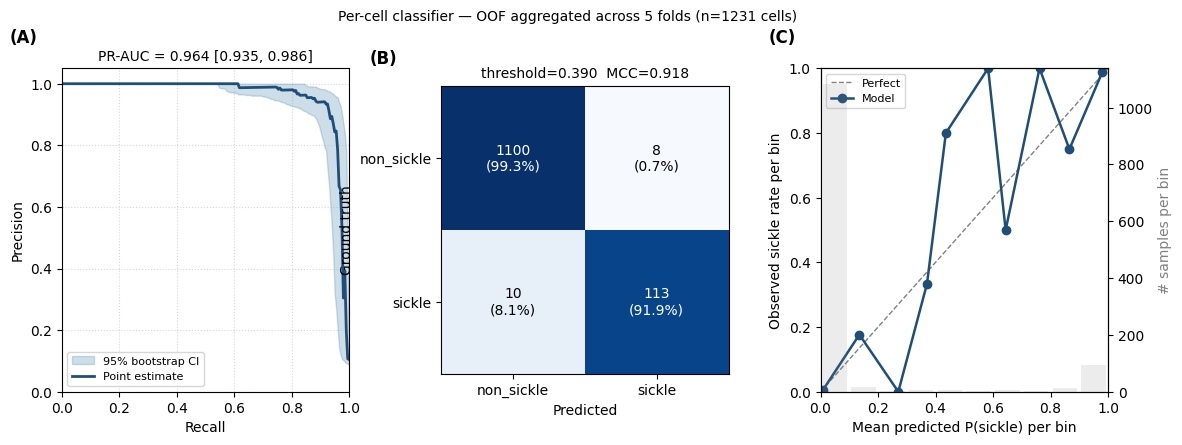

wrote E:\utku g leica\rbc-class\figures\2026-06-09\supplementary_figure_Y.svg
wrote E:\utku g leica\rbc-class\figures\2026-06-09\supplementary_figure_Y.png


In [10]:
# Composite supplementary figure (per-cell classifier, OOF aggregated):
# PR + confusion matrix + calibration. Same threshold / PR band as the
# standalone supplementary panels above.
cm_norm = cm_oof / cm_oof.sum(axis=1, keepdims=True).clip(min=1)

fig = plt.figure(figsize=(13.5, 4.2))
gs = fig.add_gridspec(1, 3, wspace=0.32)

# --- (A) PR curve with bootstrap band --------------------------------------
ax_a = fig.add_subplot(gs[0, 0])
ax_a.fill_between(
    pr_band_oof["recall_grid"], pr_band_oof["precision_low"], pr_band_oof["precision_high"],
    alpha=0.25, color="#3a7ca5", label="95% bootstrap CI",
)
ax_a.plot(pr_band_oof["recall_grid"], pr_band_oof["precision_point"],
          color="#1f4e79", linewidth=2.0, label="Point estimate")
ax_a.set_xlabel("Recall"); ax_a.set_ylabel("Precision")
ax_a.set_xlim(0, 1); ax_a.set_ylim(0, 1.05)
ax_a.grid(True, linestyle=":", alpha=0.5)
ax_a.set_title(f"PR-AUC = {pr_auc_pt:.3f} [{pr_auc_lo:.3f}, {pr_auc_hi:.3f}]", fontsize=10)
ax_a.legend(loc="lower left", fontsize=8)
ax_a.text(-0.18, 1.08, "(A)", transform=ax_a.transAxes, fontweight="bold", fontsize=12)

# --- (B) Confusion matrix at OOF-MCC-max threshold -------------------------
ax_b = fig.add_subplot(gs[0, 1])
labels = ("non_sickle", "sickle")
ax_b.imshow(cm_norm, cmap="Blues", vmin=0, vmax=1)
ax_b.set_xticks([0, 1]); ax_b.set_yticks([0, 1])
ax_b.set_xticklabels(labels); ax_b.set_yticklabels(labels)
ax_b.set_xlabel("Predicted"); ax_b.set_ylabel("Ground truth")
for i in range(2):
    for j in range(2):
        ax_b.text(j, i, f"{int(cm_oof[i, j])}\n({cm_norm[i, j]*100:.1f}%)",
                  ha="center", va="center",
                  color="white" if cm_norm[i, j] > 0.5 else "black")
ax_b.set_title(f"threshold={threshold_oof:.3f}  MCC={mcc_oof:.3f}", fontsize=10)
ax_b.text(-0.25, 1.08, "(B)", transform=ax_b.transAxes, fontweight="bold", fontsize=12)

# --- (C) Calibration plot --------------------------------------------------
ax_c = fig.add_subplot(gs[0, 2])
n_bins = 10
bins = np.linspace(0, 1, n_bins + 1)
bin_idx = np.clip(np.digitize(y_score_oof, bins) - 1, 0, n_bins - 1)
mean_pred = np.zeros(n_bins); obs_rate = np.zeros(n_bins); counts = np.zeros(n_bins, dtype=np.int64)
for b in range(n_bins):
    m = bin_idx == b
    counts[b] = int(m.sum())
    if counts[b] > 0:
        mean_pred[b] = float(y_score_oof[m].mean())
        obs_rate[b] = float(y_true_oof[m].mean())
nonempty = counts > 0
ax_c.plot([0, 1], [0, 1], color="gray", linestyle="--", linewidth=1, label="Perfect")
ax_c.plot(mean_pred[nonempty], obs_rate[nonempty], marker="o",
          color="#1f4e79", linewidth=1.8, markersize=6, label="Model")
ax_c2 = ax_c.twinx()
ax_c2.bar(bins[:-1] + (1.0 / n_bins) / 2, counts, width=(1.0 / n_bins) * 0.85,
          alpha=0.15, color="gray")
ax_c2.set_ylabel("# samples per bin", color="gray")
ax_c.set_xlabel("Mean predicted P(sickle) per bin")
ax_c.set_ylabel("Observed sickle rate per bin")
ax_c.set_xlim(0, 1); ax_c.set_ylim(0, 1)
ax_c.legend(loc="upper left", fontsize=8)
ax_c.text(-0.18, 1.08, "(C)", transform=ax_c.transAxes, fontweight="bold", fontsize=12)

fig.suptitle(f"Per-cell classifier — OOF aggregated across 5 folds (n={y_true_oof.size} cells)",
             fontsize=10, y=1.02)

supp_svg = out_dir / "supplementary_figure_Y.svg"
supp_png = out_dir / "supplementary_figure_Y.png"
fig.savefig(supp_svg, bbox_inches="tight"); fig.savefig(supp_png, dpi=300, bbox_inches="tight")
plt.show()
print("wrote", supp_svg); print("wrote", supp_png)

In [11]:
print("== v4 Deliverables (figures only) ==")
for p in [
    main_svg, main_png, stats_csv,
    ref_summary_csv, panel_c_csv, pps_csv,
    supp_svg, supp_png,
    panel_a_svg, panel_a_pdf, panel_c_svg, panel_c_pdf,
]:
    print("  ", p)

== v4 Deliverables (figures only) ==
   E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_biology.svg
   E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_biology.png
   E:\utku g leica\rbc-class\figures\2026-06-09\main_figure_stats.csv
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_B_per_group_polymer.csv
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_mean_sickle_fraction.csv
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_B_polymer_per_sickle.csv
   E:\utku g leica\rbc-class\figures\2026-06-09\supplementary_figure_Y.svg
   E:\utku g leica\rbc-class\figures\2026-06-09\supplementary_figure_Y.png
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_A_pr_curve.svg
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_A_pr_curve.pdf
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_calibration.svg
   E:\utku g leica\rbc-class\figures\2026-06-09\panel_C_calibration.pdf
